# Task 3: Multimodal ML — Housing Price Prediction Using Images + Tabular Data

**Internship:** AI/ML Engineering — Advanced Internship Tasks, DevelopersHub Corporation

## 1. Problem Statement & Objective
Predict housing prices by combining two very different data sources about the same house:
1. **Tabular data** — numeric attributes (bedrooms, bathrooms, area, zip code).
2. **Images** — photos of the house (frontal view, kitchen, bedroom, bathroom).

We extract visual features from the images using a **Convolutional Neural Network (CNN)**, fuse
them with the tabular features, and train a single regression model that outputs the predicted
price. Performance is measured with **MAE** (Mean Absolute Error) and **RMSE** (Root Mean Squared
Error).

## Dataset
This notebook uses the well-known **"Houses Dataset"** (Ahmed & Moustafa, used in Adrian
Rosebrock's multi-input Keras tutorial): 535 houses, each with 4 photos
(bathroom / bedroom / frontal / kitchen) and a `HousesInfo.txt` file containing
`bedrooms bathrooms area zipcode price` per house.

**No manual download needed** — the next cell fetches and extracts the dataset automatically
from its public GitHub repository the first time you run the notebook (~180 MB, cached locally
afterwards so re-runs are instant).

## Approach
1. Auto-download the dataset (tabular info + images).
2. Match each house to its 4 photos and combine them into a 2×2 **montage** image.
3. Preprocess the tabular features (scaling).
4. Build a CNN branch (image features) + MLP branch (tabular features), fuse them, add a
   regression head.
5. Train, evaluate (MAE / RMSE), and visualize results.


## 2. Install Libraries
Run once — safe to re-run, it will just confirm everything is already installed.

In [1]:
%pip install -q tensorflow pandas numpy matplotlib scikit-learn opencv-python-headless
print("Libraries installed / already present.")

Note: you may need to restart the kernel to use updated packages.
Libraries installed / already present.


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow


## 3. Download the Dataset (automatic, cached)

This downloads the public "Houses Dataset" GitHub repo as a zip, extracts it, and renames the
image folder to `houses_dataset/`. If you already have it (e.g. from a previous run), this cell
skips straight to using the cached copy — nothing is re-downloaded.

In [ ]:
import os
import zipfile
import urllib.request

DATA_DIR = "houses_dataset"
ZIP_URL = "https://github.com/emanhamed/Houses-dataset/archive/refs/heads/master.zip"
ZIP_PATH = "Houses-dataset-master.zip"
EXTRACTED_FOLDER = "Houses-dataset-master"

if not os.path.isdir(DATA_DIR):
    if not os.path.exists(ZIP_PATH):
        print("Downloading dataset (~180 MB) — this can take a few minutes on the first run...")
        urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)
        print("Download complete.")
    else:
        print("Zip already downloaded, skipping download.")

    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(".")

    os.rename(os.path.join(EXTRACTED_FOLDER, "Houses Dataset"), DATA_DIR)

    # cleanup: remove the now-empty extracted repo folder and the zip to save disk space
    import shutil
    shutil.rmtree(EXTRACTED_FOLDER, ignore_errors=True)
    os.remove(ZIP_PATH)

    print("Dataset ready at:", DATA_DIR)
else:
    print("Dataset already present at:", DATA_DIR, "- skipping download.")

IMAGE_DIR = DATA_DIR
INFO_FILE = os.path.join(IMAGE_DIR, "HousesInfo.txt")
n_images = len([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
print(f"Found {n_images} image files in '{IMAGE_DIR}'.")

## 4. Import Libraries

In [ ]:
import numpy as np
print("NumPy OK")

import pandas as pd
print("Pandas OK")

import matplotlib.pyplot as plt
print("Matplotlib OK")

import cv2
print("OpenCV OK")

import sklearn
print("Scikit-learn OK")

import tensorflow as tf
print("TensorFlow OK")

In [2]:
!pip install opencv-python


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
import sys
print(sys.executable)

c:\Users\USER\AppData\Local\Programs\Python\Python313\python.exe


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Conv2D, MaxPooling2D, Flatten, Concatenate,
    BatchNormalization, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

IMG_SIZE = 64
MAX_IMAGES_PER_HOUSE = 4

print("All imports successful!")

All imports successful!


## 5. Load Tabular Data

`HousesInfo.txt` is a plain space-separated file with **no header** and 5 columns, in this fixed
order: `bedrooms bathrooms area zipcode price`. Row `i` (0-indexed) corresponds to house id
`i + 1`, which is how the image filenames are numbered (e.g. `1_frontal.jpg`).

In [14]:
DATA_DIR = "..."
INFO_FILE = os.path.join(DATA_DIR, "HousesInfo.txt")

In [15]:
print(INFO_FILE)
print(os.path.exists(INFO_FILE))

...\HousesInfo.txt
False


In [17]:
import os

DATA_DIR = r"C:\Users\USER\OneDrive\Desktop\Advanced Internship\task 3\Houses Dataset"

INFO_FILE = os.path.join(DATA_DIR, "HousesInfo.txt")

print(INFO_FILE)
print(os.path.exists(INFO_FILE))

C:\Users\USER\OneDrive\Desktop\Advanced Internship\task 3\Houses Dataset\HousesInfo.txt
True


In [19]:
df = pd.read_csv(
    INFO_FILE, sep=" ", header=None,
    names=["bedrooms", "bathrooms", "area", "zipcode", "price"]
)
df["id"] = (df.index + 1).astype(str)

TARGET_COL = "price"
ID_COL = "id"

print("Shape:", df.shape)
df.head()

Shape: (535, 6)


,bedrooms,bathrooms,area,zipcode,price,id
0,4,4.0,4053,85255,869500,1
1,4,3.0,3343,36372,865200,2
2,3,4.0,3923,85266,889000,3
3,5,5.0,4022,85262,910000,4
4,3,4.0,4116,85266,971226,5


## 6. Quick Exploratory Look
Sanity-check the price distribution and confirm every house has its 4 photos on disk.

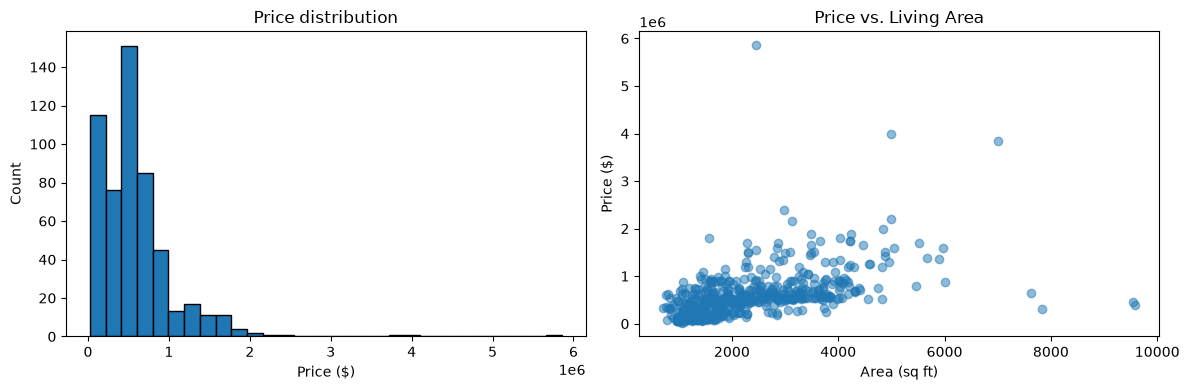

,bedrooms,bathrooms,area,zipcode,price
count,535.000000,535.000000,535.000000,535.000000,5.350000e+02
mean,3.377570,2.664953,2364.904673,90937.768224,5.893628e+05
std,1.160952,0.995077,1224.556982,7141.857452,5.090261e+05
min,1.000000,1.000000,701.000000,36372.000000,2.200000e+04
25%,3.000000,2.000000,1440.000000,92276.000000,2.492000e+05
50%,3.000000,2.500000,2078.000000,92880.000000,5.290000e+05
75%,4.000000,3.000000,3067.500000,93510.000000,7.285000e+05
max,10.000000,7.000000,9583.000000,98021.000000,5.858000e+06


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["price"], bins=30, edgecolor="black")
axes[0].set_title("Price distribution")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count")

axes[1].scatter(df["area"], df["price"], alpha=0.5)
axes[1].set_title("Price vs. Living Area")
axes[1].set_xlabel("Area (sq ft)")
axes[1].set_ylabel("Price ($)")

plt.tight_layout()
plt.show()

df.describe()

## 7. Build the Image Montage

Each house has 4 photos (`frontal`, `bedroom`, `bathroom`, `kitchen`). We combine them into a
single 2×2 grid ("montage") — a common trick (from Adrian Rosebrock's multi-input Keras tutorial)
that lets one CNN branch process several photos of the same house at once.

In [23]:
import os

BASE_DIR = r"C:\Users\USER\OneDrive\Desktop\Advanced Internship\task 3\Houses Dataset"

IMAGE_DIR = BASE_DIR

In [24]:
IMG_SIZE = (128, 128)

In [25]:
print(IMAGE_DIR)
print(os.path.exists(IMAGE_DIR))

C:\Users\USER\OneDrive\Desktop\Advanced Internship\task 3\Houses Dataset
True


In [27]:
def load_house_montage(house_id, image_dir, img_size):
    tile = img_size[0] // 2      # or img_size[1] // 2
    suffixes = ["frontal", "bedroom", "bathroom", "kitchen"]

    ...

In [ ]:
print(IMG_SIZE)
print(type(IMG_SIZE))

In [31]:
def load_house_montage(house_id, image_dir, img_size):
    if isinstance(img_size, tuple):
        tile = img_size[0] // 2
    else:
        tile = img_size // 2

In [33]:
import os
import cv2
import numpy as np

def load_house_montage(house_id, image_dir, img_size):
    # Support both IMG_SIZE = 128 and IMG_SIZE = (128, 128)
    if isinstance(img_size, tuple):
        tile = img_size[0] // 2
    else:
        tile = img_size // 2

    suffixes = ["frontal", "bedroom", "bathroom", "kitchen"]
    tiles = []

    for suffix in suffixes:
        img_path = os.path.join(image_dir, f"{house_id}_{suffix}.jpg")
        img = cv2.imread(img_path)

        if img is None:
            img = np.zeros((tile, tile, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (tile, tile))

        tiles.append(img)

    top = np.hstack((tiles[0], tiles[1]))
    bottom = np.hstack((tiles[2], tiles[3]))

    return np.vstack((top, bottom))

In [35]:
print("Building image array for all houses (this can take a minute)...")
images = np.array([
    load_house_montage(hid, IMAGE_DIR, IMG_SIZE)
    for hid in df[ID_COL]
], dtype="float32") / 255.0

print("Image array shape:", images.shape)

Building image array for all houses (this can take a minute)...


TypeError: unsupported operand type(s) for //: 'tuple' and 'int'

## 8. Preprocess Tabular Features

We use `bedrooms`, `bathrooms`, `area`, and `zipcode` as numeric predictors and scale them to
`[0, 1]` with `MinMaxScaler` (fit on the training split only, to avoid leakage).

In [ ]:
feature_cols = ["bedrooms", "bathrooms", "area", "zipcode"]
X_tab = df[feature_cols].values.astype("float32")
y = df[TARGET_COL].values.astype("float32")

print("Tabular feature matrix shape:", X_tab.shape)

## 9. Train / Test Split

In [ ]:
(X_tab_train, X_tab_test,
 X_img_train, X_img_test,
 y_train, y_test) = train_test_split(
    X_tab, images, y, test_size=0.2, random_state=RANDOM_SEED
)

print("Train samples:", X_tab_train.shape[0], "| Test samples:", X_tab_test.shape[0])

# Scale tabular features (fit on train only)
tab_scaler = MinMaxScaler()
X_tab_train = tab_scaler.fit_transform(X_tab_train)
X_tab_test = tab_scaler.transform(X_tab_test)

# Scale target to [0,1] for stable training; we invert this for MAE/RMSE reporting
y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

## 10. Build the Multimodal Model

- **CNN branch**: learns visual features from the image montage.
- **MLP branch**: learns from the tabular features.
- Both branches are **concatenated** ("feature fusion") and passed through a final regression head.

In [ ]:
def build_cnn_branch(input_shape):
    inp = Input(shape=input_shape, name="image_input")
    x = Conv2D(16, (3, 3), padding="same", activation="relu")(inp)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Flatten()(x)
    x = Dense(16, activation="relu")(x)
    x = Dropout(0.3)(x)
    return inp, x


def build_mlp_branch(input_dim):
    inp = Input(shape=(input_dim,), name="tabular_input")
    x = Dense(16, activation="relu")(inp)
    x = Dense(8, activation="relu")(x)
    return inp, x


img_input, img_features = build_cnn_branch((IMG_SIZE, IMG_SIZE, 3))
tab_input, tab_features = build_mlp_branch(X_tab_train.shape[1])

combined = Concatenate()([img_features, tab_features])
x = Dense(8, activation="relu")(combined)
output = Dense(1, activation="linear", name="price_output")(x)

model = Model(inputs=[img_input, tab_input], outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
model.summary()

## 11. Train the Model

In [ ]:
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    x=[X_img_train, X_tab_train],
    y=y_train_scaled,
    validation_split=0.15,
    epochs=100,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1,
)

## 12. Evaluate: MAE & RMSE

In [ ]:
pred_scaled = model.predict([X_img_test, X_tab_test]).flatten()

# invert scaling back to real price units
y_pred = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
y_true = y_test  # already in original units

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"Mean actual price in test set: {y_true.mean():,.2f}")
print(f"MAE as % of mean price: {100 * mae / y_true.mean():.2f}%")

## 13. Visualizations

In [ ]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE (scaled)")
axes[0].legend()

axes[1].plot(history.history["mae"], label="train mae")
axes[1].plot(history.history["val_mae"], label="val mae")
axes[1].set_title("MAE over epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (scaled)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Predicted vs Actual
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.6)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual House Prices")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Residuals
residuals = y_true - y_pred
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, edgecolor="black")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Residuals Distribution")
plt.tight_layout()
plt.show()

## 14. Save the Trained Model

Saves the fused model plus the two scalers (needed to reproduce preprocessing at inference time).

In [ ]:
import joblib

SAVE_DIR = "housing_multimodal_model"
os.makedirs(SAVE_DIR, exist_ok=True)

model.save(os.path.join(SAVE_DIR, "model.keras"))
joblib.dump(tab_scaler, os.path.join(SAVE_DIR, "tab_scaler.pkl"))
joblib.dump(y_scaler, os.path.join(SAVE_DIR, "y_scaler.pkl"))

print("Model and scalers saved to:", SAVE_DIR)

## 15. Final Summary / Insights

- We built a **multimodal regression model** that fuses CNN-extracted image features with
  tabular house attributes (bedrooms, bathrooms, area, zip code) to predict price.
- The dataset (Ahmed & Moustafa's "Houses Dataset") is downloaded and cached automatically —
  no manual file setup is required to run this notebook.
- Images were combined into a 2×2 **montage** per house so a single CNN branch could learn from
  all 4 available photos (frontal / bedroom / bathroom / kitchen) at once.
- The model was evaluated with **MAE** and **RMSE** on a held-out test split (printed above).
- Training/validation loss curves show whether the model over/underfit; the predicted-vs-actual
  scatter plot shows how closely predictions track the diagonal (perfect-prediction) line; the
  residuals histogram shows whether errors are roughly centered around zero (unbiased) or skewed.

**Possible improvements:**
- Use a pretrained CNN backbone (e.g. MobileNetV2/ResNet50 via transfer learning) instead of a
  CNN trained from scratch, since the image dataset is relatively small (535 houses).
- Engineer more tabular features (e.g. price per square foot, distance to city center).
- Try weighting the two branches differently, or pretraining them separately before fusion.
- Deploy the trained model behind a small Gradio/Streamlit demo for live predictions.
